<a href="https://colab.research.google.com/github/priyanka0178885547/DL-lab/blob/main/Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


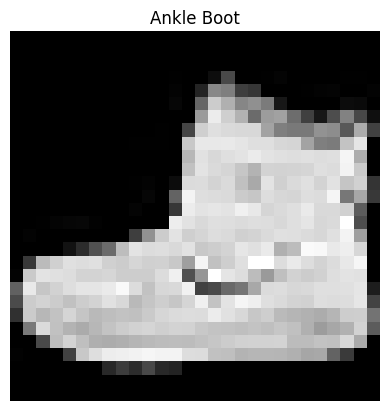

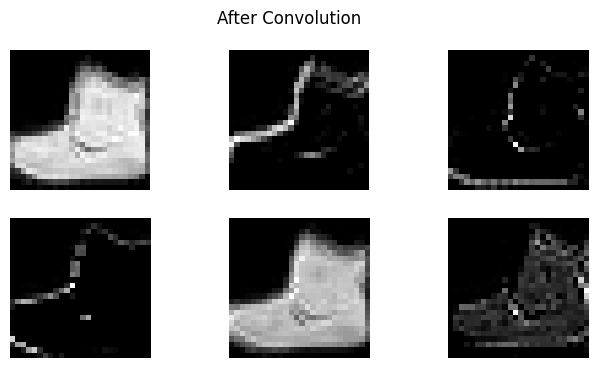

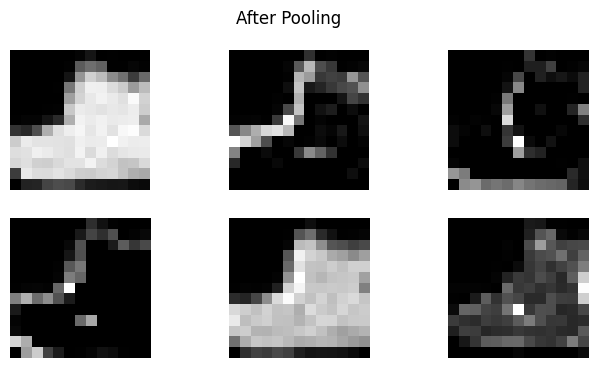

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), _ = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train / 255.0
x_train = x_train.reshape(-1,28,28,1)

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

image = x_train[0]
label = y_train[0]

inputs = Input(shape=(28,28,1))
conv = layers.Conv2D(6, (3,3), activation='relu')(inputs)
pool = layers.MaxPooling2D((2,2))(conv)

model = models.Model(inputs=inputs, outputs=[conv, pool])

feature_maps = model.predict(np.expand_dims(image, axis=0))
conv_out, pool_out = feature_maps

def plot_maps(feature_maps, title):
    num_maps = feature_maps.shape[-1]
    plt.figure(figsize=(8,4))
    for i in range(num_maps):
        plt.subplot(2, num_maps//2, i+1)
        plt.imshow(feature_maps[0,:,:,i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plt.imshow(image.squeeze(), cmap='gray')
plt.title(classes[label])
plt.axis('off')
plt.show()

plot_maps(conv_out, "After Convolution")
plot_maps(pool_out, "After Pooling")

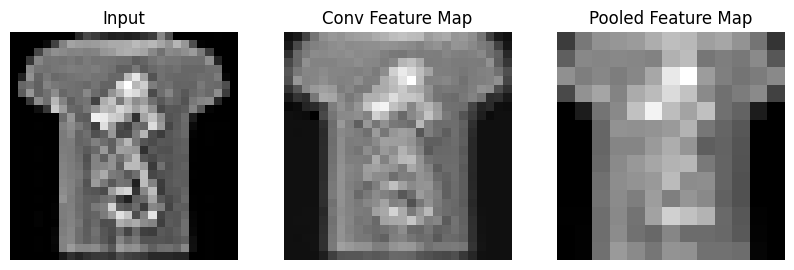

Input Shape: torch.Size([1, 1, 28, 28])
After Conv: torch.Size([1, 6, 26, 26])
After ReLU: torch.Size([1, 6, 26, 26])
After Pool: torch.Size([1, 6, 13, 13])


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

image, label = next(iter(loader))

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, stride=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        conv = self.conv1(x)
        relu = self.relu(conv)
        pool = self.pool(relu)
        return conv, relu, pool

model = CNN()
conv_out, relu_out, pool_out = model(image)

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.title("Input")
plt.imshow(image[0][0].detach().numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Conv Feature Map")
plt.imshow(conv_out[0][0].detach().numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Pooled Feature Map")
plt.imshow(pool_out[0][0].detach().numpy(), cmap='gray')
plt.axis('off')

plt.show()

print("Input Shape:", image.shape)
print("After Conv:", conv_out.shape)
print("After ReLU:", relu_out.shape)
print("After Pool:", pool_out.shape)

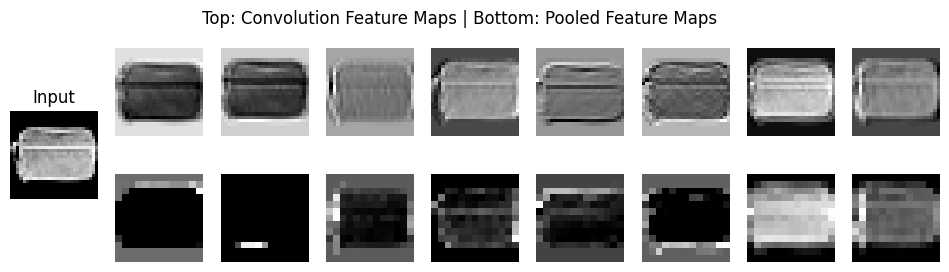

Input Shape: torch.Size([1, 1, 28, 28])
Conv Output Shape: torch.Size([1, 8, 26, 26])
Pool Output Shape: torch.Size([1, 8, 13, 13])


In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

image, label = next(iter(loader))

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        conv = self.conv1(x)
        relu = self.relu(conv)
        pool = self.pool(relu)
        return conv, pool

model = CNN()
conv_out, pool_out = model(image)

plt.figure(figsize=(12,3))
plt.subplot(1,9,1)
plt.imshow(image[0][0].detach().numpy(), cmap='gray')
plt.title("Input")
plt.axis('off')

for i in range(8):
    plt.subplot(2,9,i+2)
    plt.imshow(conv_out[0][i].detach().numpy(), cmap='gray')
    plt.axis('off')

for i in range(8):
    plt.subplot(2,9,i+11)
    plt.imshow(pool_out[0][i].detach().numpy(), cmap='gray')
    plt.axis('off')

plt.suptitle("Top: Convolution Feature Maps | Bottom: Pooled Feature Maps")
plt.show()

print("Input Shape:", image.shape)
print("Conv Output Shape:", conv_out.shape)
print("Pool Output Shape:", pool_out.shape)

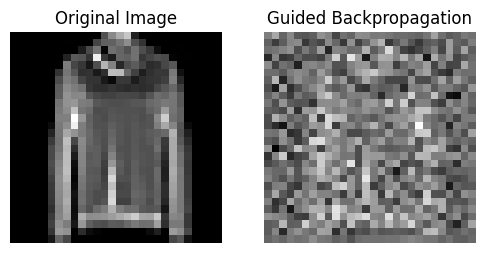

Predicted Class: 5
Gradient Shape: (28, 28)


In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

image, label = next(iter(loader))
image.requires_grad = True

class GuidedReLU(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return torch.clamp(x, min=0)

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        grad_input = grad_output.clone()
        grad_input[x < 0] = 0
        grad_input[grad_output < 0] = 0
        return grad_input

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 8, 3)
        self.fc = nn.Linear(8*26*26, 10)

    def forward(self, x):
        x = self.conv(x)
        x = GuidedReLU.apply(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = Net()

output = model(image)
pred_class = output.argmax()

model.zero_grad()
output[0, pred_class].backward()

gradients = image.grad[0][0].detach().numpy()

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image[0][0].detach().numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Guided Backpropagation")
plt.imshow(gradients, cmap='gray')
plt.axis('off')

plt.show()

print("Predicted Class:", pred_class.item())
print("Gradient Shape:", gradients.shape)